In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "C:/Users/LENOVO/Desktop/Kavi docu/jobs/f1-business-analytics/data/processed/f1_clean_analytics_dataset.csv",
    dtype={'number': 'string'},
    low_memory=False
)



In [2]:
df.shape
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27238 entries, 0 to 27237
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   resultId                 27238 non-null  int64  
 1   raceId                   27238 non-null  int64  
 2   driverId                 27238 non-null  int64  
 3   constructorId            27238 non-null  int64  
 4   number                   27238 non-null  string 
 5   grid                     27238 non-null  float64
 6   position                 27238 non-null  float64
 7   positionText             27238 non-null  object 
 8   positionOrder            27238 non-null  int64  
 9   points                   27238 non-null  float64
 10  laps                     27238 non-null  int64  
 11  statusId                 27238 non-null  int64  
 12  dnf                      27238 non-null  int64  
 13  year                     27238 non-null  int64  
 14  round                 

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,forename,surname,dob,nationality,constructorRef,name_constructor,nationality_constructor,driver_name,season,grid_vs_finish
0,1,18,1,1,22,1.0,1.0,1,1,10.0,...,Lewis,Hamilton,1985-01-07,British,mclaren,McLaren,British,Lewis Hamilton,2008,0.0
1,2,18,2,2,3,5.0,2.0,2,2,8.0,...,Nick,Heidfeld,1977-05-10,German,bmw_sauber,BMW Sauber,German,Nick Heidfeld,2008,3.0
2,3,18,3,3,7,7.0,3.0,3,3,6.0,...,Nico,Rosberg,1985-06-27,German,williams,Williams,British,Nico Rosberg,2008,4.0
3,4,18,4,4,5,11.0,4.0,4,4,5.0,...,Fernando,Alonso,1981-07-29,Spanish,renault,Renault,French,Fernando Alonso,2008,7.0
4,5,18,5,1,23,3.0,5.0,5,5,4.0,...,Heikki,Kovalainen,1981-10-19,Finnish,mclaren,McLaren,British,Heikki Kovalainen,2008,-2.0


In [3]:
df.describe()


,resultId,raceId,driverId,constructorId,grid,position,positionOrder,points,laps,statusId,dnf,year,round,circuitId,season,grid_vs_finish
count,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000,27238.000000
mean,13620.548131,562.323482,287.189037,50.916807,11.115574,4.838534,12.753359,2.041672,46.457926,17.053124,0.402122,1991.985351,8.581467,23.975953,1991.985351,6.277039
std,7864.483958,320.515332,289.313608,62.430841,7.185049,5.480000,7.642542,4.434966,29.342136,25.986529,0.490335,20.263955,5.135663,19.355725,20.263955,7.654952
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1950.000000,1.000000,1.000000,1950.000000,-27.000000
25%,6810.250000,304.000000,59.000000,6.000000,5.000000,0.000000,6.000000,0.000000,23.000000,1.000000,0.000000,1977.000000,4.000000,9.000000,1977.000000,0.000000
50%,13619.500000,539.000000,173.000000,25.000000,11.000000,3.000000,12.000000,0.000000,53.000000,10.000000,0.000000,1992.000000,8.000000,18.000000,1992.000000,4.000000
75%,20431.750000,824.000000,427.000000,63.000000,17.000000,9.000000,18.000000,2.000000,66.000000,14.000000,1.000000,2010.000000,12.000000,34.000000,2010.000000,11.000000
max,27243.000000,1168.000000,865.000000,215.000000,34.000000,33.000000,39.000000,50.000000,200.000000,141.000000,1.000000,2025.000000,24.000000,80.000000,2025.000000,34.000000


In [4]:
df.isnull().sum().sort_values(ascending=False)


resultId                   0
raceId                     0
season                     0
driver_name                0
nationality_constructor    0
name_constructor           0
constructorRef             0
nationality                0
dob                        0
surname                    0
forename                   0
code                       0
number_driver              0
driverRef                  0
time_race                  0
date                       0
name                       0
circuitId                  0
round                      0
year                       0
dnf                        0
statusId                   0
laps                       0
points                     0
positionOrder              0
positionText               0
position                   0
grid                       0
number                     0
constructorId              0
driverId                   0
grid_vs_finish             0
dtype: int64

In [5]:
df.groupby('season')['raceId'].nunique()


season
1950     7
1951     8
1952     8
1953     9
1954     9
        ..
2021    22
2022    22
2023    22
2024    24
2025    24
Name: raceId, Length: 76, dtype: int64

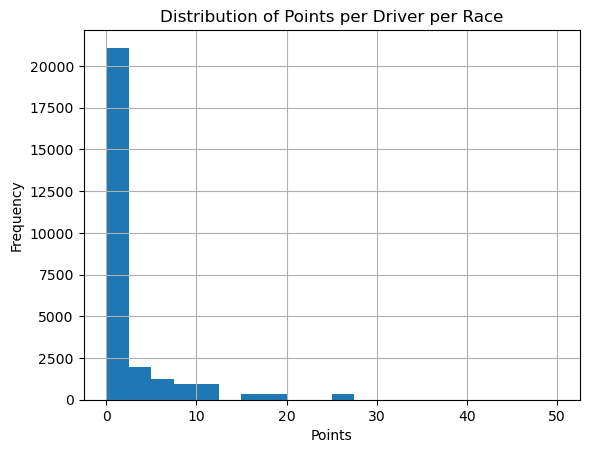

In [6]:
import matplotlib.pyplot as plt

df['points'].hist(bins=20)
plt.title("Distribution of Points per Driver per Race")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()


In [7]:
df['dnf'].value_counts()


dnf
0    16285
1    10953
Name: count, dtype: int64

In [8]:
df[['grid', 'position']].corr()


,grid,position
grid,1.000000,0.292795
position,0.292795,1.000000


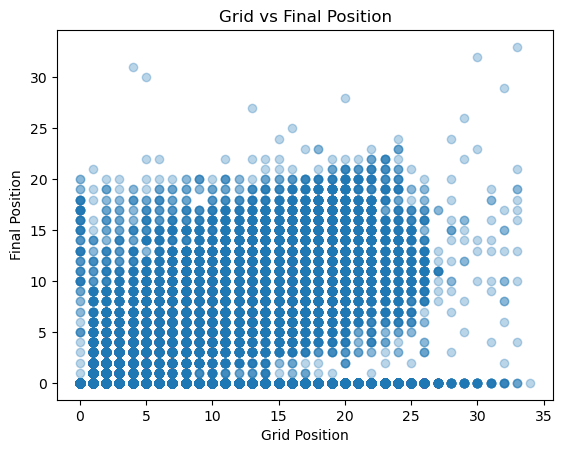

In [9]:
plt.scatter(df['grid'], df['position'], alpha=0.3)
plt.xlabel("Grid Position")
plt.ylabel("Final Position")
plt.title("Grid vs Final Position")
plt.show()


In [10]:
df.groupby('name_constructor')['points'].mean().sort_values(ascending=False).head(10)


name_constructor
Mercedes        11.649486
Red Bull         9.668660
Brawn            5.058824
Ferrari          4.604451
Lotus F1         4.584416
McLaren          3.956114
Racing Point     3.723684
Matra-Ford       3.250000
Force India      2.589623
Epperly          2.588235
Name: points, dtype: float64

In [11]:
df.groupby('driver_name')['points'].agg(['mean','std']).sort_values('mean', ascending=False).head(10)


,mean,std
driver_name,,
Max Verstappen,14.169528,9.333974
Lewis Hamilton,13.040789,9.051686
Oscar Piastri,10.400000,8.443160
Sebastian Vettel,10.326667,8.948382
Charles Leclerc,9.179191,7.187459
Lando Norris,8.842105,7.732365
Nico Rosberg,7.740291,8.672456
Valtteri Bottas,7.238866,7.869594
George Russell,6.269737,6.787182


In [12]:
df.groupby(['season','name_constructor'])['points'].sum().reset_index()


,season,name_constructor,points
0,1950,Adams,0.0
1,1950,Alfa Romeo,89.0
2,1950,Alta,0.0
3,1950,Cooper,0.0
4,1950,Deidt,10.0
...,...,...,...
1116,2025,Mercedes,424.0
1117,2025,RB F1 Team,88.0
1118,2025,Red Bull,410.0
1119,2025,Sauber,70.0


In [13]:
df.groupby('nationality')['driverId'].nunique().sort_values(ascending=False).head(10)


nationality
British          166
American         158
Italian          100
French            74
German            50
Brazilian         33
Argentine         24
South African     23
Belgian           23
Swiss             23
Name: driverId, dtype: int64

In [14]:
df['grid_vs_finish']


0        0.0
1        3.0
2        4.0
3        7.0
4       -2.0
        ... 
27233    1.0
27234   -8.0
27235   -5.0
27236    0.0
27237    0.0
Name: grid_vs_finish, Length: 27238, dtype: float64

In [15]:
df.groupby('driver_name')['grid_vs_finish'].mean().sort_values(ascending=False).head(10)


driver_name
Oswald Karch      34.0
Erwin Bauer       33.0
Bill Mackey       33.0
Ernst Loof        31.0
Günther Bechem    30.0
Danny Kladis      29.0
Graham McRae      28.0
Jo Vonlanthen     28.0
Art Bisch         28.0
Chet Miller       27.5
Name: grid_vs_finish, dtype: float64

In [16]:
kpi = {
    "Total Seasons": df['season'].nunique(),
    "Total Races": df['raceId'].nunique(),
    "Total Drivers": df['driverId'].nunique(),
    "Total Constructors": df['constructorId'].nunique(),
    "Average Points per Race": df['points'].mean(),
    "DNF Rate (%)": df['dnf'].mean() * 100
}

kpi


{'Total Seasons': 76,
 'Total Races': 1149,
 'Total Drivers': 864,
 'Total Constructors': 211,
 'Average Points per Race': 2.041671561788678,
 'DNF Rate (%)': 40.21220353917322}

In [17]:
latest_year = df['season'].max()
latest_year


2025

In [18]:
start_year = latest_year - 10
start_year


2015

In [19]:
df_10yr = df[df['season'] >= start_year].copy()


In [20]:
df_10yr['season'].min(), df_10yr['season'].max()


(2015, 2025)

In [21]:
df_10yr.shape


(4698, 32)

In [22]:
df_10yr.describe()


,resultId,raceId,driverId,constructorId,grid,position,positionOrder,points,laps,statusId,dnf,year,round,circuitId,season,grid_vs_finish
count,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000,4698.000000
mean,24892.371648,1046.800341,662.335675,74.347808,10.240741,8.052576,10.590464,5.022456,53.964453,9.698595,0.136441,2020.160281,11.185185,28.683482,2020.160281,2.188165
std,1358.895246,70.565224,333.214851,86.983856,5.904079,5.805924,5.830186,7.188812,17.827164,22.193563,0.343293,3.204090,6.252628,26.878433,3.204090,5.958119
min,22538.000000,926.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,2015.000000,1.000000,1.000000,2015.000000,-20.000000
25%,23716.250000,985.000000,807.000000,5.000000,5.000000,3.000000,6.000000,0.000000,51.000000,1.000000,0.000000,2017.000000,6.000000,9.000000,2017.000000,-1.000000
50%,24894.500000,1044.000000,830.000000,10.000000,10.000000,8.000000,11.000000,0.000000,56.000000,1.000000,0.000000,2020.000000,11.000000,17.000000,2020.000000,1.000000
75%,26068.750000,1110.000000,844.000000,131.000000,15.000000,13.000000,16.000000,8.000000,67.000000,11.000000,0.000000,2023.000000,16.000000,39.000000,2023.000000,5.000000
max,27243.000000,1168.000000,865.000000,215.000000,22.000000,22.000000,22.000000,26.000000,87.000000,141.000000,1.000000,2025.000000,24.000000,80.000000,2025.000000,22.000000


In [23]:
df_10yr.groupby('season')['points'].mean()


season
2015    5.076720
2016    4.590909
2017    5.050000
2018    5.050000
2019    5.095238
2020    5.100000
2021    4.976136
2022    5.095455
2023    5.095455
2024    5.100209
2025    5.060543
Name: points, dtype: float64

In [24]:
cols_to_drop = [
    'fp1_date','fp1_time','fp2_date','fp2_time','fp3_date','fp3_time',
    'quali_date','quali_time','sprint_date','sprint_time',
    'time_x','time_y','fastestLapTime'
]

df_10yr.drop(columns=[c for c in cols_to_drop if c in df_10yr.columns], inplace=True)


In [25]:
df_10yr.drop(columns=['url','url_x','url_y'], inplace=True, errors='ignore')


In [26]:
df_10yr.groupby('season')['raceId'].nunique()


season
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24
2025    24
Name: raceId, dtype: int64

In [27]:
df_10yr.groupby('name_constructor')['points'].sum().sort_values(ascending=False).head(10)


name_constructor
Mercedes          6433.5
Red Bull          5217.5
Ferrari           4713.5
McLaren           2616.0
Williams           684.0
Force India        607.0
Aston Martin       572.0
Alpine F1 Team     518.0
Renault            459.0
Haas F1 Team       366.0
Name: points, dtype: float64

In [28]:
df_10yr.groupby('driver_name')['points'].agg(['mean','std']).sort_values('mean', ascending=False).head(10)


,mean,std
driver_name,,
Nico Rosberg,17.675000,7.596853
Lewis Hamilton,14.954741,8.637674
Max Verstappen,14.169528,9.333974
Oscar Piastri,10.400000,8.443160
Sebastian Vettel,9.192547,8.340051
Charles Leclerc,9.179191,7.187459
Lando Norris,8.842105,7.732365
Valtteri Bottas,7.645933,7.933558
Sergio Pérez,6.748792,6.617474


In [29]:
df_10yr[['grid','position']].corr()


,grid,position
grid,1.000000,0.482337
position,0.482337,1.000000


In [30]:
df_10yr.groupby('season')['dnf'].mean() * 100


season
2015    19.841270
2016    17.099567
2017    21.500000
2018    19.047619
2019    11.904762
2020    15.588235
2021    11.818182
2022    14.545455
2023    12.272727
2024    10.020877
2025     0.000000
Name: dnf, dtype: float64

In [31]:
top_drivers = (
    df_10yr.groupby('driver_name')['points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_drivers


driver_name
Lewis Hamilton      3469.5
Max Verstappen      3301.5
Valtteri Bottas     1598.0
Charles Leclerc     1588.0
Sebastian Vettel    1480.0
Sergio Pérez        1397.0
Lando Norris        1344.0
Carlos Sainz        1257.5
Daniel Ricciardo    1052.0
George Russell       953.0
Name: points, dtype: float64

In [32]:
driver_perf = (
    df_10yr.groupby('driver_name')['points']
    .agg(['mean', 'std'])
    .sort_values('mean', ascending=False)
)

driver_perf.head(10)


,mean,std
driver_name,,
Nico Rosberg,17.675000,7.596853
Lewis Hamilton,14.954741,8.637674
Max Verstappen,14.169528,9.333974
Oscar Piastri,10.400000,8.443160
Sebastian Vettel,9.192547,8.340051
Charles Leclerc,9.179191,7.187459
Lando Norris,8.842105,7.732365
Valtteri Bottas,7.645933,7.933558
Sergio Pérez,6.748792,6.617474


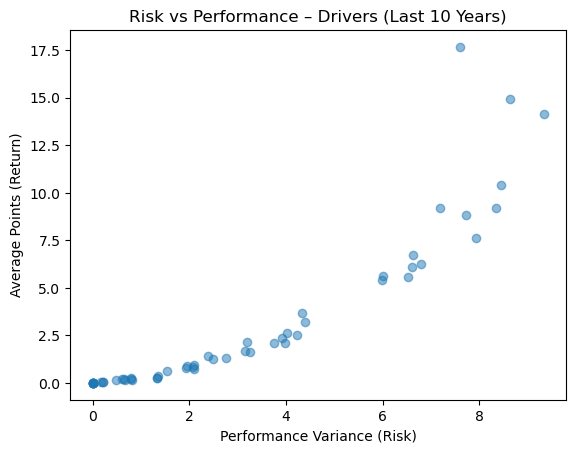

In [33]:
import matplotlib.pyplot as plt

plt.scatter(driver_perf['std'], driver_perf['mean'], alpha=0.5)
plt.xlabel("Performance Variance (Risk)")
plt.ylabel("Average Points (Return)")
plt.title("Risk vs Performance – Drivers (Last 10 Years)")
plt.show()


In [34]:
constructor_perf = (
    df_10yr.groupby('name_constructor')['points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

constructor_perf


name_constructor
Mercedes          6433.5
Red Bull          5217.5
Ferrari           4713.5
McLaren           2616.0
Williams           684.0
Force India        607.0
Aston Martin       572.0
Alpine F1 Team     518.0
Renault            459.0
Haas F1 Team       366.0
Name: points, dtype: float64

In [35]:
df_10yr.groupby('name_constructor')['points'].agg(['mean','std']).sort_values('mean', ascending=False).head(10)


,mean,std
name_constructor,,
Mercedes,13.805794,8.155567
Red Bull,11.196352,8.784919
Ferrari,10.114807,7.059365
McLaren,5.613734,7.117217
Force India,3.746914,3.893476
Racing Point,3.723684,5.193839
Aston Martin,2.519824,4.125606
Renault,2.295000,3.706300
Alpine F1 Team,2.271930,3.891219


In [36]:
df_10yr[['grid', 'position']].corr()


,grid,position
grid,1.000000,0.482337
position,0.482337,1.000000


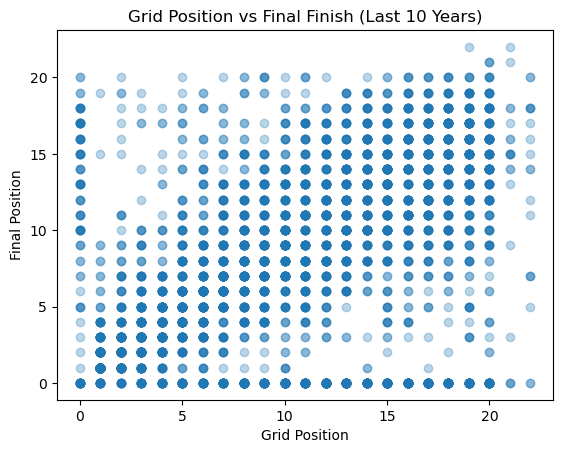

In [37]:
plt.scatter(df_10yr['grid'], df_10yr['position'], alpha=0.3)
plt.xlabel("Grid Position")
plt.ylabel("Final Position")
plt.title("Grid Position vs Final Finish (Last 10 Years)")
plt.show()


In [38]:
df_10yr['grid_vs_finish'].describe()


count    4698.000000
mean        2.188165
std         5.958119
min       -20.000000
25%        -1.000000
50%         1.000000
75%         5.000000
max        22.000000
Name: grid_vs_finish, dtype: float64

In [39]:
df_10yr.groupby('driver_name')['grid_vs_finish'].mean().sort_values(ascending=False).head(10)


driver_name
Paul di Resta        19.000000
Jolyon Palmer         7.000000
Pastor Maldonado      6.631579
Jenson Button         6.609756
Brendon Hartley       6.200000
Rio Haryanto          6.166667
Marcus Ericsson       5.839506
Nikita Mazepin        5.545455
Pascal Wehrlein       5.461538
Stoffel Vandoorne     5.404762
Name: grid_vs_finish, dtype: float64

In [40]:
constructor_risk = (
    df_10yr.groupby('name_constructor')['points']
    .agg(['mean','std'])
    .sort_values('mean', ascending=False)
)

constructor_risk.head(10)


,mean,std
name_constructor,,
Mercedes,13.805794,8.155567
Red Bull,11.196352,8.784919
Ferrari,10.114807,7.059365
McLaren,5.613734,7.117217
Force India,3.746914,3.893476
Racing Point,3.723684,5.193839
Aston Martin,2.519824,4.125606
Renault,2.295000,3.706300
Alpine F1 Team,2.271930,3.891219


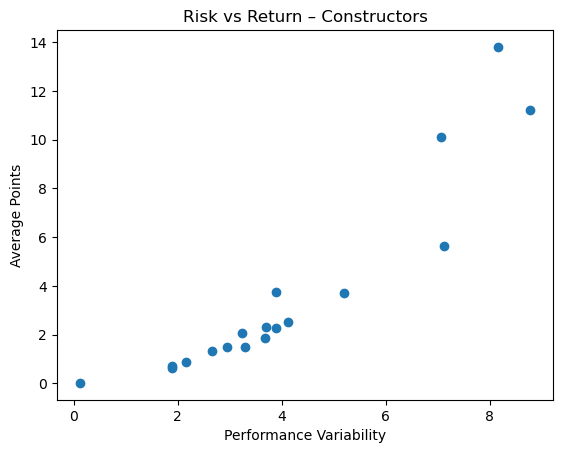

In [41]:
plt.scatter(constructor_risk['std'], constructor_risk['mean'])
plt.xlabel("Performance Variability")
plt.ylabel("Average Points")
plt.title("Risk vs Return – Constructors")
plt.show()


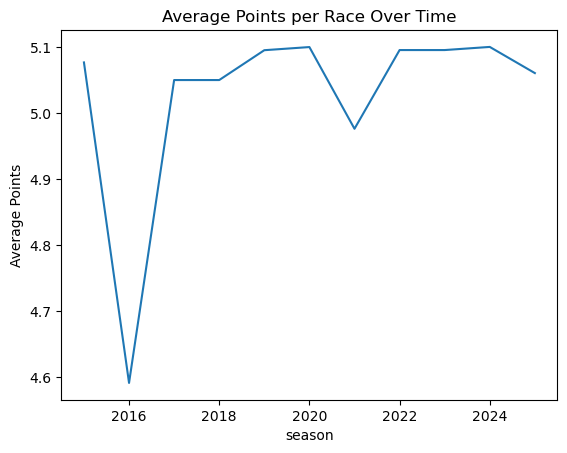

In [42]:
season_points = df_10yr.groupby('season')['points'].mean()

season_points.plot(kind='line', title='Average Points per Race Over Time')
plt.ylabel("Average Points")
plt.show()


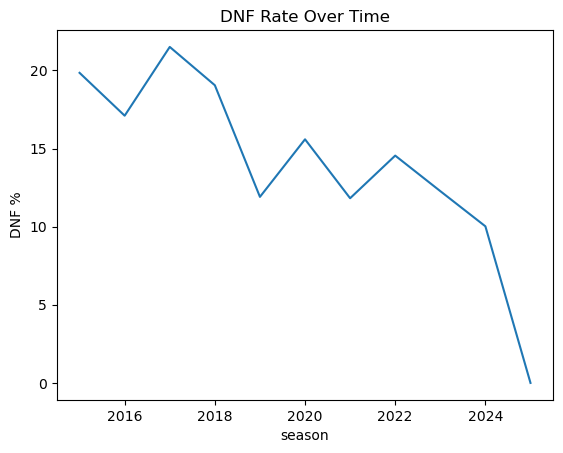

In [43]:
dnf_trend = df_10yr.groupby('season')['dnf'].mean() * 100

dnf_trend.plot(kind='line', title='DNF Rate Over Time')
plt.ylabel("DNF %")
plt.show()


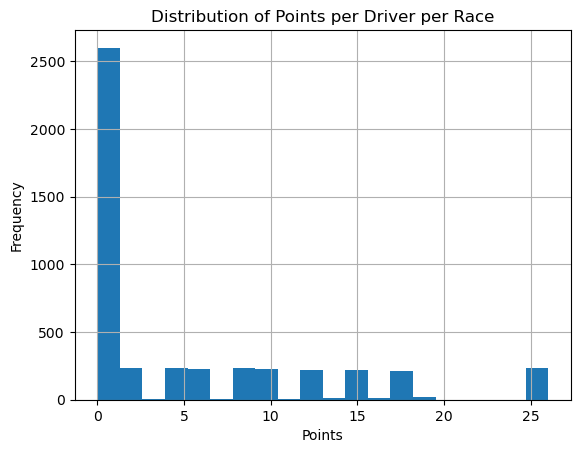

In [44]:
df_10yr['points'].hist(bins=20)
plt.title("Distribution of Points per Driver per Race")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()


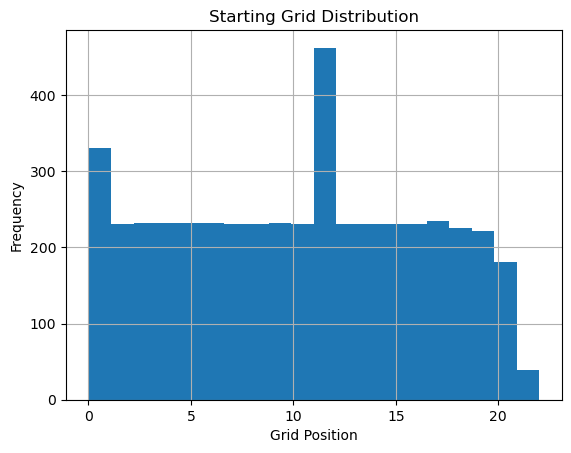

In [45]:
df_10yr['grid'].hist(bins=20)
plt.title("Starting Grid Distribution")
plt.xlabel("Grid Position")
plt.ylabel("Frequency")
plt.show()


In [46]:
corr = df_10yr[['grid', 'position', 'points', 'laps', 'dnf']].corr()
corr


,grid,position,points,laps,dnf
grid,1.000000,0.482337,-0.623045,-0.074045,0.083265
position,0.482337,1.000000,-0.547508,0.327079,-0.551361
points,-0.623045,-0.547508,1.000000,0.239899,-0.277736
laps,-0.074045,0.327079,0.239899,1.000000,-0.708261
dnf,0.083265,-0.551361,-0.277736,-0.708261,1.000000


FEATURE ENGINEERING

In [47]:
driver_features = (
    df_10yr.groupby('driver_name')
    .agg(
        races=('raceId', 'count'),
        total_points=('points', 'sum'),
        avg_points=('points', 'mean'),
        points_std=('points', 'std'),
        avg_grid=('grid', 'mean'),
        avg_finish=('position', 'mean'),
        dnf_rate=('dnf', 'mean'),
        avg_grid_vs_finish=('grid_vs_finish', 'mean')
    )
    .reset_index()
)


In [48]:
driver_features['consistency_index'] = (
    driver_features['avg_points'] / (driver_features['points_std'] + 1)
)


In [49]:
driver_features['efficiency_score'] = (
    driver_features['avg_points'] / (driver_features['avg_grid'] + 1)
)


In [50]:
def min_max(s):
    return (s - s.min()) / (s.max() - s.min())

driver_features['performance_index'] = (
    0.5 * min_max(driver_features['avg_points']) +
    0.3 * (1 - driver_features['dnf_rate']) +
    0.2 * min_max(driver_features['avg_grid_vs_finish'])
)


In [51]:
driver_features['roi_proxy'] = (
    driver_features['total_points'] /
    (driver_features['races'] + 1)
)


In [52]:
driver_features['performance_volatility'] = driver_features['points_std'].fillna(0)


In [53]:
high_perf_threshold = driver_features['avg_points'].quantile(0.75)

driver_features['high_performer_flag'] = (
    driver_features['avg_points'] >= high_perf_threshold
).astype(int)

driver_features['reliable_driver_flag'] = (
    (driver_features['dnf_rate'] < driver_features['dnf_rate'].median()) &
    (driver_features['consistency_index'] > driver_features['consistency_index'].median())
).astype(int)


In [54]:
constructor_features = (
    df_10yr.groupby('name_constructor')
    .agg(
        races=('raceId', 'count'),
        total_points=('points', 'sum'),
        avg_points=('points', 'mean'),
        dnf_rate=('dnf', 'mean')
    )
    .reset_index()
)


In [55]:
constructor_features['performance_index'] = min_max(constructor_features['avg_points'])


In [56]:
driver_features.describe()
driver_features.isnull().sum()


driver_name               0
races                     0
total_points              0
avg_points                0
points_std                2
avg_grid                  0
avg_finish                0
dnf_rate                  0
avg_grid_vs_finish        0
consistency_index         2
efficiency_score          0
performance_index         0
roi_proxy                 0
performance_volatility    0
high_performer_flag       0
reliable_driver_flag      0
dtype: int64

In [57]:
driver_features[
    ['performance_index','efficiency_score','consistency_index','roi_proxy']
].corr()


,performance_index,efficiency_score,consistency_index,roi_proxy
performance_index,1.000000,0.881483,0.958814,0.984692
efficiency_score,0.881483,1.000000,0.868723,0.890672
consistency_index,0.958814,0.868723,1.000000,0.974671
roi_proxy,0.984692,0.890672,0.974671,1.000000
